## CNN on the CIFAR-10 Dataset

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=32, shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=32, shuffle=False
)

100%|██████████| 170M/170M [00:04<00:00, 39.3MB/s]


In [ ]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)
        return x

In [ ]:
def train_model(model, trainloader, optimizer, criterion, epochs=10):
    train_losses = []

    for epoch in range(epochs):
        running_loss = 0.0

        for images, labels in trainloader:
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(trainloader)
        train_losses.append(epoch_loss)

        print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

    return train_losses

In [ ]:
def evaluate_model(model, testloader):
    correct = 0
    total = 0

    model.eval()
    with torch.no_grad():
        for images, labels in testloader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print("Test Accuracy:", accuracy)
    return accuracy

In [ ]:
model = ImprovedCNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

losses = train_model(model, trainloader, optimizer, criterion, epochs=10)

evaluate_model(model, testloader)

Epoch 1, Loss: 1.4501
Epoch 2, Loss: 1.1034
Epoch 3, Loss: 0.9832
Epoch 4, Loss: 0.9111
Epoch 5, Loss: 0.8469
Epoch 6, Loss: 0.8078
Epoch 7, Loss: 0.7746
Epoch 8, Loss: 0.7325
Epoch 9, Loss: 0.7085
Epoch 10, Loss: 0.6777
Test Accuracy: 71.11


71.11

In [ ]:
learning_rates = [0.1, 0.01, 0.001]

for lr in learning_rates:
    print(f"\nTraining with LR = {lr}")

    model = ImprovedCNN()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_model(model, trainloader, optimizer, criterion, epochs=5)
    evaluate_model(model, testloader)


Training with LR = 0.1
Epoch 1, Loss: 3.4458
Epoch 2, Loss: 2.3143
Epoch 3, Loss: 2.3161
Epoch 4, Loss: 2.3154
Epoch 5, Loss: 2.3148
Test Accuracy: 10.0

Training with LR = 0.01
Epoch 1, Loss: 2.3093
Epoch 2, Loss: 2.3039
Epoch 3, Loss: 2.3039
Epoch 4, Loss: 2.3040
Epoch 5, Loss: 2.3039
Test Accuracy: 10.0

Training with LR = 0.001
Epoch 1, Loss: 1.4503
Epoch 2, Loss: 1.1316
Epoch 3, Loss: 0.9896
Epoch 4, Loss: 0.9039
Epoch 5, Loss: 0.8414
Test Accuracy: 72.3


In [ ]:
batch_sizes = [16, 32, 64]

for bs in batch_sizes:
    print(f"\nBatch Size = {bs}")

    trainloader = torch.utils.data.DataLoader(trainset, batch_size=bs, shuffle=True)

    model = ImprovedCNN()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_model(model, trainloader, optimizer, criterion, epochs=5)
    evaluate_model(model, testloader)


Batch Size = 16
Epoch 1, Loss: 1.4742
Epoch 2, Loss: 1.1645
Epoch 3, Loss: 1.0398
Epoch 4, Loss: 0.9632
Epoch 5, Loss: 0.9066
Test Accuracy: 71.35

Batch Size = 32
Epoch 1, Loss: 1.4568
Epoch 2, Loss: 1.1078
Epoch 3, Loss: 0.9868
Epoch 4, Loss: 0.9086
Epoch 5, Loss: 0.8567
Test Accuracy: 71.71

Batch Size = 64
Epoch 1, Loss: 1.4662
Epoch 2, Loss: 1.1107
Epoch 3, Loss: 0.9665
Epoch 4, Loss: 0.8832
Epoch 5, Loss: 0.8214
Test Accuracy: 69.68


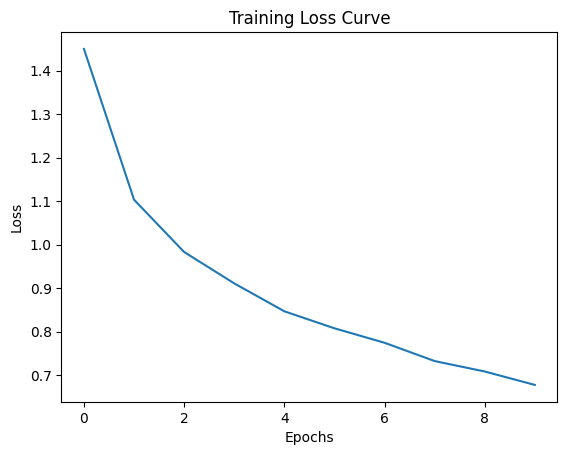

In [ ]:
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

## CNN on the CIFAR-10 Dataset

In [ ]:
# import libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import plot_model

import matplotlib.pyplot as plt

In [ ]:
# loading dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten labels
y_train = y_train.flatten()
y_test = y_test.flatten()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
# train-validation split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size = 0.2, random_state=42)

In [ ]:
# Improved CNN model
# Extra Conv layer
# Increased filters (32 → 64)
# BatchNorm
# Dropout
def build_cnn(learning_rate = 0.001, dropout_rate = 0.5):

    model = keras.Sequential([
        # Conv Block 1
        layers.Conv2D(32, kernel_size = (3,3), padding = 'same', activation = 'relu', input_shape = (32,32,3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Conv Block 2
        layers.Conv2D(64, kernel_size = (3,3), padding = 'same', activation = 'relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Conv Block 3 (extra layer)
        layers.Conv2D(64, kernel_size = (3,3), padding = 'same', activation = 'relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),

        layers.Dense(128, activation = 'relu'),
        layers.Dropout(dropout_rate),

        layers.Dense(10, activation = 'softmax')])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])

    return model

In [ ]:
# early stopping
early_stopping = keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True)

In [ ]:
# training base model
model = build_cnn()

history = model.fit(X_train, y_train, validation_data = (X_val, y_val), epochs = 15, batch_size = 32, callbacks = [early_stopping])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 128s 100ms/step - accuracy: 0.4207 - loss: 1.5962 - val_accuracy: 0.5378 - val_loss: 1.2942
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 137s 96ms/step - accuracy: 0.5599 - loss: 1.2413 - val_accuracy: 0.5132 - val_loss: 1.3971
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 146s 100ms/step - accuracy: 0.6236 - loss: 1.0736 - val_accuracy: 0.6542 - val_loss: 0.9812
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 129s 103ms/step - accuracy: 0.6630 - loss: 0.9609 - val_accuracy: 0.6531 - val_loss: 0.9987
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 124s 100ms/step - accuracy: 0.6909 - loss: 0.8841 - val_accuracy: 0.6505 - val_loss: 1.0131
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 141s 99ms/step - accuracy: 0.7129 - loss: 0.8204 - val_accuracy: 0.6876 - val_loss: 0.8866
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 147s 103ms/step - accuracy: 0.7307 - loss: 0.7655 - val_accuracy: 0.6942 - val_loss: 0.8811
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 124s 99ms/step - accur

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,200 (2.16 MB)

 Trainable params: 189,002 (738.29 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 378,006 (1.44 MB)

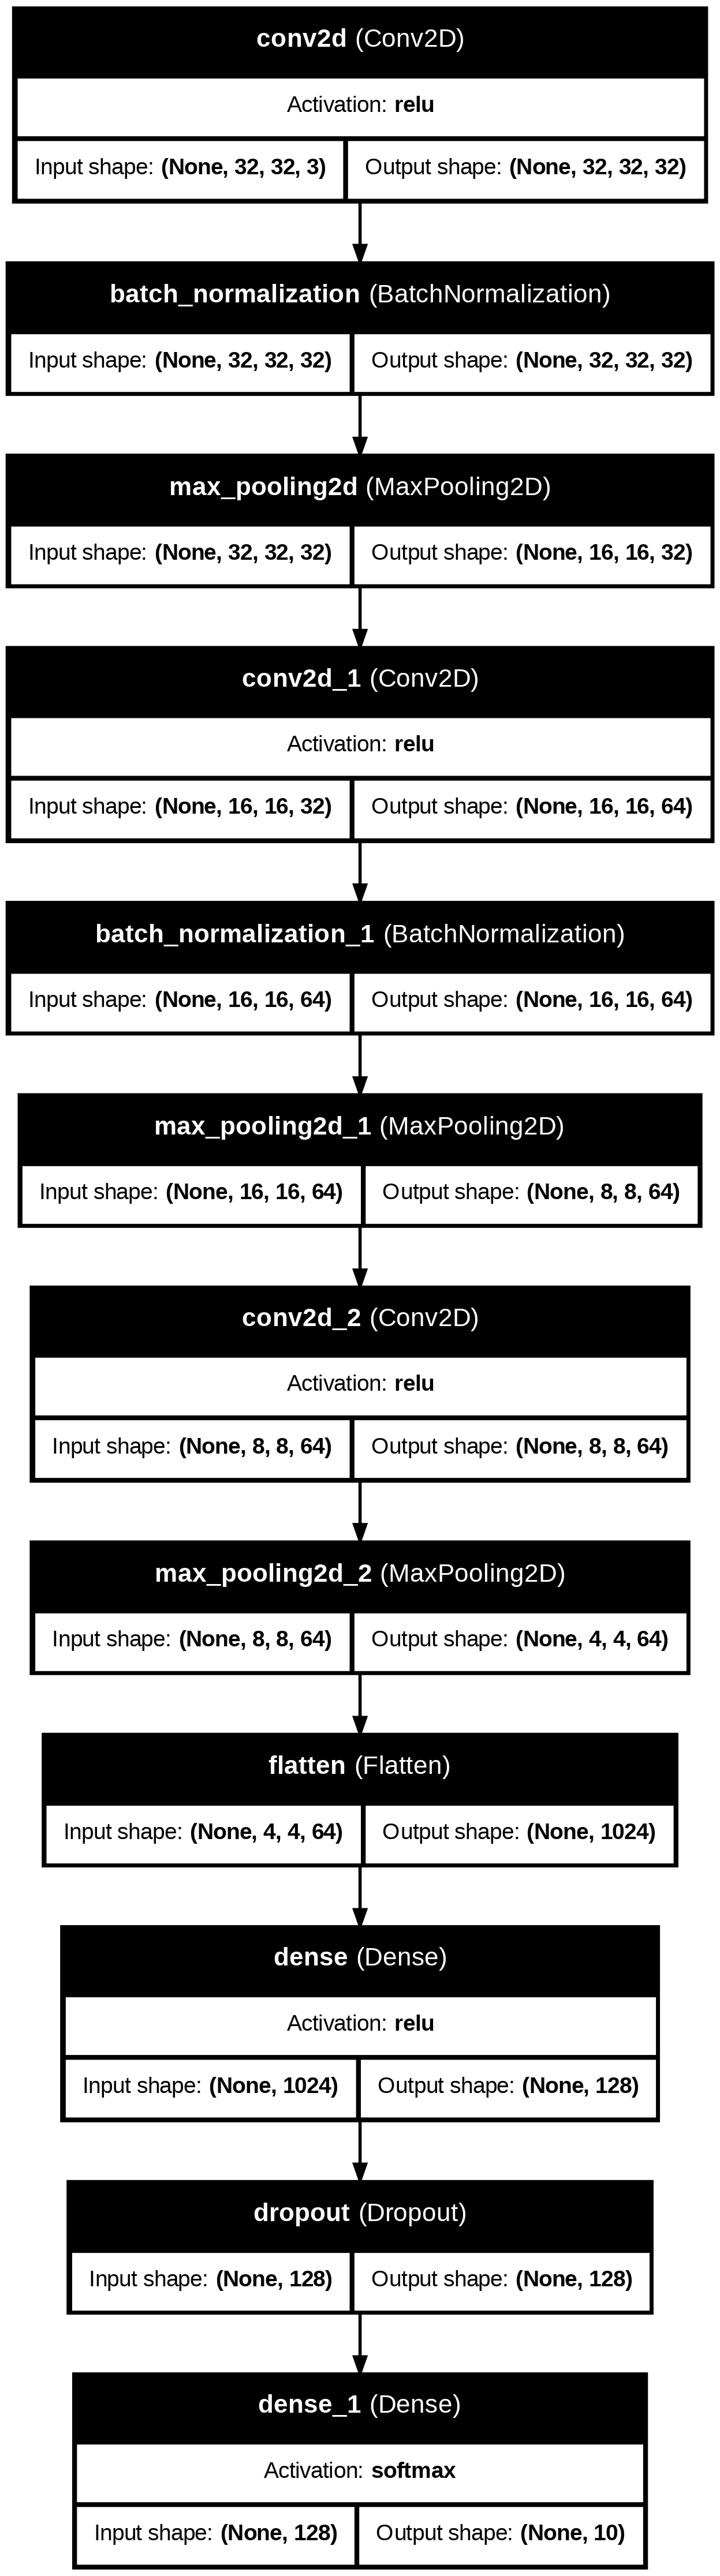

In [ ]:
plot_model(model, show_shapes = True, show_layer_names = True, show_layer_activations = True)

In [ ]:
# evaluation on test data
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7315 - loss: 0.8342
Test Accuracy: 0.7315000295639038


In [ ]:
# Hyperparameter tuning
learning_rates = [0.1, 0.01, 0.001]

for lr in learning_rates:
    print(f"\nTraining with LR = {lr}")

    model = build_cnn(learning_rate=lr)

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=32,
        verbose=0)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print("Accuracy:", acc)


Training with LR = 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.10000000149011612

Training with LR = 0.01
Accuracy: 0.4178999960422516

Training with LR = 0.001
Accuracy: 0.7225000262260437


In [ ]:
# Accuracy on the different batch size
batch_sizes = [16, 32, 64]

for bs in batch_sizes:
    print(f"\nBatch Size = {bs}")

    model = build_cnn()

    model.fit(
        X_train, y_train,
        validation_data = (X_val, y_val),
        epochs = 5,
        batch_size = bs,
        verbose = 0
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print("Accuracy:", acc)


Batch Size = 16
Accuracy: 0.678600013256073

Batch Size = 32
Accuracy: 0.6765999794006348

Batch Size = 64
Accuracy: 0.5846999883651733


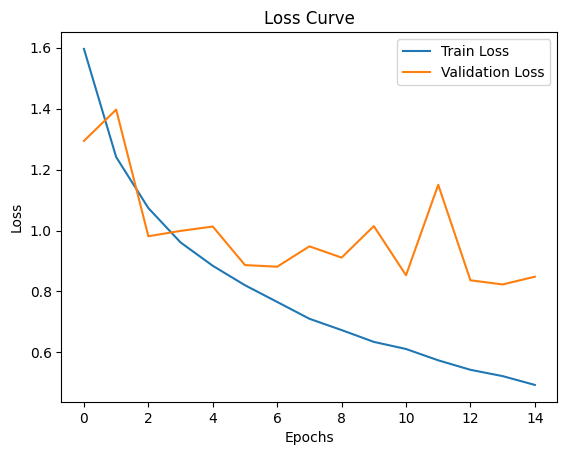

In [ ]:
# plot loss curve (Training and Validation Loss)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()